In [1]:
import os
import sys
import importlib
import pandas as pd
from sklearn.linear_model import Ridge

import utils
import evaluation_metrics as em
from datasets import load_dataset
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)
importlib.reload(utils)

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from '/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py'>

# TF1 Experiments

## HKAN

In [2]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [3]:
print("TF1 train describe")
display(pd.DataFrame(tf1_x_train).describe())
print("TF1 test describe")
display(pd.DataFrame(tf1_x_test).describe())
print("TF1 y_train describe")
display(pd.Series(tf1_y_train).describe())
print("TF1 y_test describe")
display(pd.Series(tf1_y_test).describe())

TF1 train describe


,0,1
count,5000.000000,5000.000000
mean,0.502492,0.498871
std,0.291808,0.285606
min,0.000021,0.000020
25%,0.247467,0.253435
50%,0.504131,0.497807
75%,0.758499,0.743126
max,0.999705,0.999692


TF1 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250000,0.250000
50%,0.500000,0.500000
75%,0.750000,0.750000
max,1.000000,1.000000


TF1 y_train describe


count    5000.000000
mean        0.505381
std         0.166339
min         0.009263
25%         0.414095
50%         0.501150
75%         0.600623
max         0.988818
dtype: float64

TF1 y_test describe


count    10000.000000
mean         0.500000
std          0.170042
min          0.000000
25%          0.404882
50%          0.500000
75%          0.595118
max          1.000000
dtype: float64

In [4]:
# TF1 HKAN model params
tf1_model_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
tf1_model = utils.build_hkan_from_params(tf1_model_params)
tf1_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,932
,n_basis,2
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Si...t 0x17da145d0>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [5]:
# Fit HKAN for TF1
utils.fit_hkan(tf1_model,  tf1_x_train, tf1_y_train)
tf1_results = em.evaluate(
    tf1_model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.82it/s]



✓ HKAN training completed in 4.1559 seconds


In [6]:
em.print_results(tf1_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.625217e-11         1.927906e-11        
RMSE            2.166573e-11         4.696504e-11        


✓ HKAN prediction completed in 2.4119 seconds


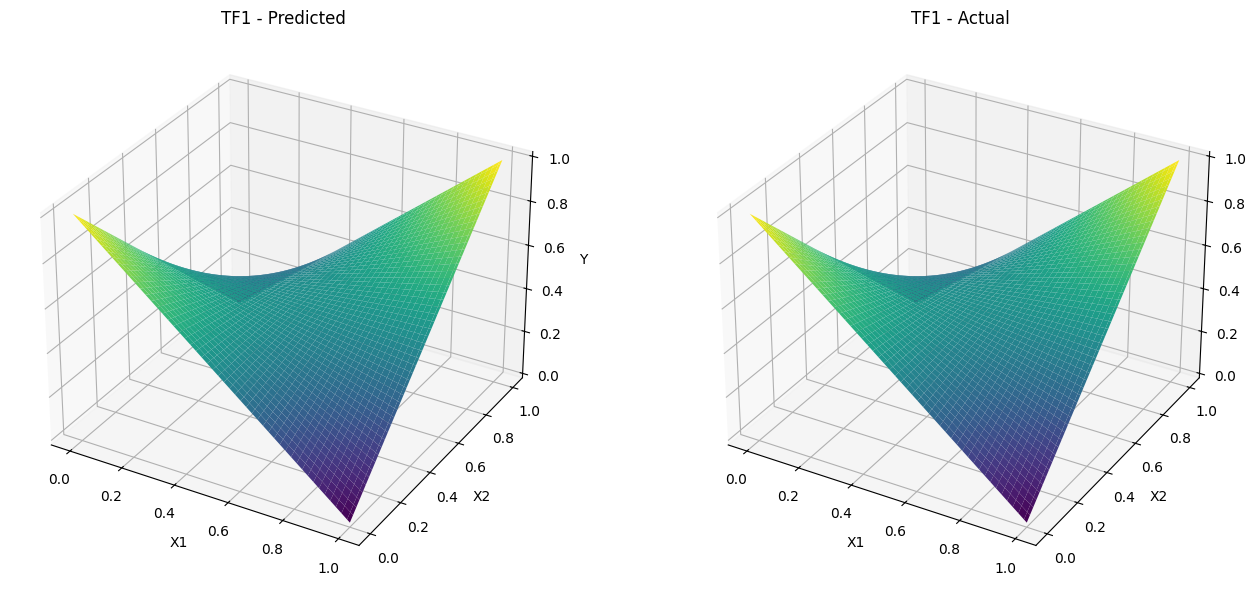

In [7]:
tf1_y_test_pred = utils.predict_hkan(tf1_model, tf1_x_test)
utils.plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_y_test_pred)

## KAN

In [8]:
tf1_kan_study = utils.study_optuna_kan("TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_trials = 10)

Results found for TF1. Loading from data/tf1_kan_optuna_search.csv
Best CV Validation RMSE: 0.161730
Best Test RMSE:          0.172035
Best width_idx:          2
Best architecture:       [2, 3, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.161730                 2  0.161730   0.172035
1       1  0.568877                 8  0.568877   0.274214
2       2  0.168665                 4  0.168665   0.298363
3       3  3.752602                 9  3.752602   0.568879
4       4  0.174820                 1  0.174820   0.179805
5       5  0.245464                 6  0.245464   0.178054
6       6  0.198778                 7  0.198778   0.172921
7       7  0.198986                 3  0.198986   0.190309
8       8  0.166398                 0  0.166398   0.170176
9       9  0.573112                 5  0.573112   1.370827


In [9]:
# Create TF1 KAN model with best architecture
tf1_kan_model = utils.build_kan(width=tf1_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [10]:
# Train and test TF1 KAN model
utils.fit_kan(tf1_kan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, steps=100, opt="Adam", lamb=1e-3)

tf1_kan_results = em.evaluate(
    utils.KANModel(tf1_kan_model),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 2.88e+01 | : 100%|█| 100/100 [00:25<00:00,  3.89

saving model version 0.1

✓ KAN training completed in 25.7665 seconds


In [11]:
em.print_results(tf1_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.261283e-01         1.289797e-01        
RMSE            1.681006e-01         1.720347e-01        


In [12]:
tf1_y_test_pred_kan = utils.predict_kan(tf1_kan_model, tf1_x_test)

✓ KAN prediction completed in 0.0226 seconds


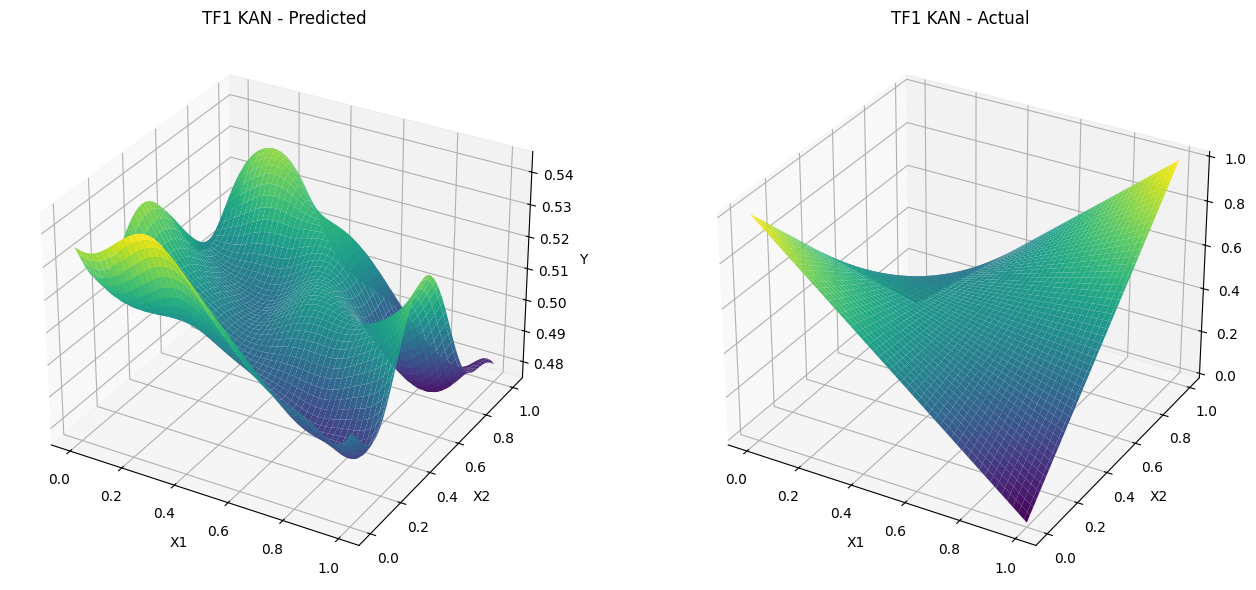

In [13]:
utils.plot_3d_surface("TF1 KAN", tf1_x_test, tf1_y_test, tf1_y_test_pred_kan)

## GP

In [ ]:
print("\nTraining GP...")
kernel = utils.create_periodic_linear_kernel(tf1_x_train.shape[1])
tf1_gp_model, tf1_gp_likelihood = utils.init_and_fit_gp(tf1_x_train, tf1_y_train, kernel, num_inducing=388, lr=0.002930)

# Evaluate GP model
print("\nEvaluating GP...")
tf1_gp = utils.GPModel(tf1_gp_model, tf1_gp_likelihood)
tf1_gp_results = em.evaluate(
    tf1_gp,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

em.print_results(tf1_gp_results)

# Make predictions for visualization
tf1_gp_y_test_pred = tf1_gp.predict(tf1_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=388

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.843747
  Iter 200/500, Loss: 0.800470
  Iter 300/500, Loss: 0.784691
  Iter 400/500, Loss: 0.777575
  Iter 500/500, Loss: 0.773242
[DEBUG] Training complete.
  Lengthscale: tensor([[1.2908, 1.2629]])
  Outputscale: 0.5039
  Noise: 0.693247
  Mean const: 0.2209
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             1.245791e-01         1.282506e-01        
RMSE            1.664061e-01         1.711157e-01        
[DEBUG] SparseGPModel and likelihood frozen (eval mode

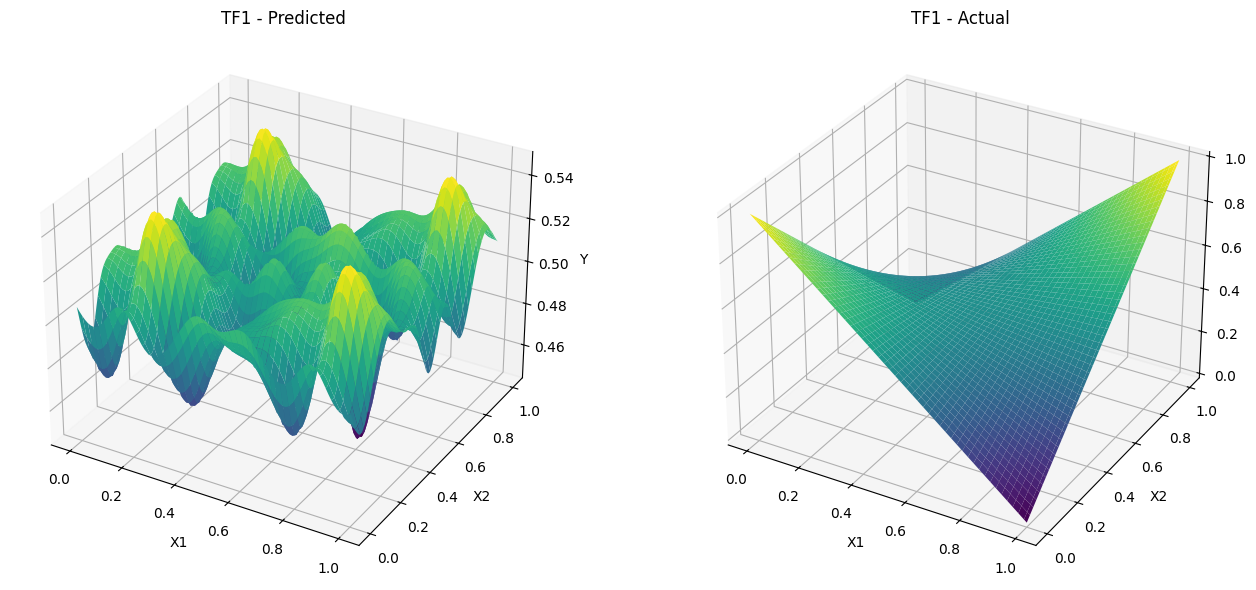

In [19]:
utils.plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_gp_y_test_pred)

# TF2 Experiments

## HKAN

In [ ]:
# Load TF2 dataset
tf2 = load_dataset("TF2")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = tf2["train_input"], tf2["test_input"], tf2["train_label"], tf2["test_label"]

In [ ]:
print("TF2 train describe")
display(pd.DataFrame(tf2_x_train).describe())
print("TF2 test describe")
display(pd.DataFrame(tf2_x_test).describe())
print("TF2 y_train describe")
display(pd.Series(tf2_y_train).describe())
print("TF2 y_test describe")
display(pd.Series(tf2_y_test).describe())

In [ ]:
# TF2 HKAN model params
tf2_model_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
tf2_model = utils.build_hkan_from_params(tf2_model_params)
tf2_model

In [ ]:
# Fit HKAN for TF2
utils.fit_hkan(tf2_model, tf2_x_train, tf2_y_train)
tf2_results = em.evaluate(
    tf2_model,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

In [ ]:
em.print_results(tf2_results)

In [ ]:
tf2_y_test_pred = utils.predict_hkan(tf2_model, tf2_x_test)
utils.plot_3d_surface("TF2", tf2_x_test, tf2_y_test, tf2_y_test_pred)

## KAN

In [ ]:
tf2_kan_study = utils.study_optuna_kan("TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_trials=10)

In [ ]:
tf2_kan_model = utils.build_kan(width=tf2_kan_study["architecture"], grid=3, k=3, seed=42)

In [ ]:
utils.fit_kan(tf2_kan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, steps=100, opt="Adam", lamb=1e-3)

tf2_kan_results = em.evaluate(
    utils.KANModel(tf2_kan_model),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

In [ ]:
em.print_results(tf2_kan_results)

In [ ]:
tf2_y_test_pred_kan = utils.predict_kan(tf2_kan_model, tf2_x_test)
utils.plot_3d_surface("TF2 KAN", tf2_x_test, tf2_y_test, tf2_y_test_pred_kan)

# TF3 Experiments

## HKAN

In [ ]:
# Load TF3 dataset
tf3 = load_dataset("TF3")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = tf3["train_input"], tf3["test_input"], tf3["train_label"], tf3["test_label"]

In [ ]:
print("TF3 train describe")
display(pd.DataFrame(tf3_x_train).describe())
print("TF3 test describe")
display(pd.DataFrame(tf3_x_test).describe())
print("TF3 y_train describe")
display(pd.Series(tf3_y_train).describe())
print("TF3 y_test describe")
display(pd.Series(tf3_y_test).describe())

In [ ]:
# TF3 HKAN model params
tf3_model_params = [
    {
        "layer": 0,
        "n_vars_out": 924,
        "basis_fn": Tanh(s=50),
        "n_basis": 39,
        "centers": "random",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf3_model = utils.build_hkan_from_params(tf3_model_params)
tf3_model

In [ ]:
# Fit HKAN for TF3
utils.fit_hkan(tf3_model, tf3_x_train, tf3_y_train)
tf3_results = em.evaluate(
    tf3_model,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

In [ ]:
em.print_results(tf3_results)

In [ ]:
tf3_y_test_pred = utils.predict_hkan(tf3_model, tf3_x_test)
utils.plot_3d_surface("TF3", tf3_x_test, tf3_y_test, tf3_y_test_pred)

## KAN

In [ ]:
tf3_kan_study = utils.study_optuna_kan("TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_trials=10)

In [ ]:
tf3_kan_model = utils.build_kan(width=tf3_kan_study["architecture"], grid=3, k=3, seed=42)

In [ ]:
utils.fit_kan(tf3_kan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, steps=100, opt="Adam", lamb=1e-3)

tf3_kan_results = em.evaluate(
    utils.KANModel(tf3_kan_model),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

In [ ]:
em.print_results(tf3_kan_results)

In [ ]:
tf3_y_test_pred_kan = utils.predict_kan(tf3_kan_model, tf3_x_test)
utils.plot_3d_surface("TF3 KAN", tf3_x_test, tf3_y_test, tf3_y_test_pred_kan)

# TF4 Experiments

## HKAN

In [ ]:
# Load TF4 dataset
tf4 = load_dataset("TF4")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = tf4["train_input"], tf4["test_input"], tf4["train_label"], tf4["test_label"]

In [ ]:
print("TF4 train describe")
display(pd.DataFrame(tf4_x_train).describe())
print("TF4 test describe")
display(pd.DataFrame(tf4_x_test).describe())
print("TF4 y_train describe")
display(pd.Series(tf4_y_train).describe())
print("TF4 y_test describe")
display(pd.Series(tf4_y_test).describe())

In [ ]:
# TF4 HKAN model params
tf4_model_params = [
    {
        "layer": 0,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=3),
        "n_basis": 2,
        "centers": "equally_spaced",
        "regressor": Ridge(alpha=0.001),
    }
]
tf4_model = utils.build_hkan_from_params(tf4_model_params)
tf4_model

In [ ]:
# Fit HKAN for TF4
utils.fit_hkan(tf4_model, tf4_x_train, tf4_y_train)
tf4_results = em.evaluate(
    tf4_model,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

In [ ]:
em.print_results(tf4_results)

In [ ]:
tf4_y_test_pred = utils.predict_hkan(tf4_model, tf4_x_test)
utils.plot_3d_surface("TF4", tf4_x_test, tf4_y_test, tf4_y_test_pred)

## KAN

In [ ]:
tf4_kan_study = utils.study_optuna_kan("TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials=10)

In [ ]:
tf4_kan_model = utils.build_kan(width=tf4_kan_study["architecture"], grid=3, k=3, seed=42)

In [ ]:
utils.fit_kan(tf4_kan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, steps=100, opt="Adam", lamb=1e-3)

tf4_kan_results = em.evaluate(
    utils.KANModel(tf4_kan_model),
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

In [ ]:
em.print_results(tf4_kan_results)

In [ ]:
tf4_y_test_pred_kan = utils.predict_kan(tf4_kan_model, tf4_x_test)
utils.plot_3d_surface("TF4 KAN", tf4_x_test, tf4_y_test, tf4_y_test_pred_kan)

# TF5 Experiments

## HKAN

In [ ]:
# Load TF5 dataset
tf5 = load_dataset("TF5")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = tf5["train_input"], tf5["test_input"], tf5["train_label"], tf5["test_label"]

In [ ]:
print("TF5 train describe")
display(pd.DataFrame(tf5_x_train).describe())
print("TF5 test describe")
display(pd.DataFrame(tf5_x_test).describe())
print("TF5 y_train describe")
display(pd.Series(tf5_y_train).describe())
print("TF5 y_test describe")
display(pd.Series(tf5_y_test).describe())

In [ ]:
# tf5 HKAN model params
tf5_model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf5_model = utils.build_hkan_from_params(tf5_model_params)
tf5_model

In [ ]:
# Fit HKAN for TF5
utils.fit_hkan(tf5_model, tf5_x_train, tf5_y_train)
tf5_results = em.evaluate(
    tf5_model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
em.print_results(tf5_results)

In [ ]:
tf5_y_test_pred = utils.predict_hkan(tf5_model, tf5_x_test)
utils.plot_3d_surface("TF5", tf5_x_test, tf5_y_test, tf5_y_test_pred)

## KAN

In [ ]:
tf5_kan_study = utils.study_optuna_kan("TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_trials=10)

In [ ]:
tf5_kan_model = utils.build_kan(width=tf5_kan_study["architecture"], grid=3, k=3, seed=42)

In [ ]:
utils.fit_kan(tf5_kan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, steps=100, opt="Adam", lamb=1e-3)

tf5_kan_results = em.evaluate(
    utils.KANModel(tf5_kan_model),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
em.print_results(tf5_kan_results)

In [ ]:
tf5_y_test_pred_kan = utils.predict_kan(tf5_kan_model, tf5_x_test)
utils.plot_3d_surface("TF5 KAN", tf5_x_test, tf5_y_test, tf5_y_test_pred_kan)